In [25]:
# import packages
import pandas as pd
import numpy as np
import re, random, time
import seaborn as sns
import matplotlib.pyplot as plt

from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from afinn import Afinn
from textblob import TextBlob

import warnings
warnings.filterwarnings("ignore")

# Prepare Data

In [2]:
%%time

# file name
file_path = "../personal_envs/ngram-language-model/en_US_twitter.txt"

with open(file_path, 'r', encoding='utf-8') as f:
    lines = [line.strip() for line in f if line.strip()]

df = pd.DataFrame(lines, columns=["tweet"])
display(df.head())
print(df.shape)

,tweet
0,How are you? Btw thanks for the RT. You gonna ...
1,When you meet someone special... you'll know. ...
2,they've decided its more fun if I don't.
3,So Tired D; Played Lazer Tag & Ran A LOT D; Ug...
4,Words from a complete stranger! Made my birthd...


(2360148, 1)
CPU times: total: 1.92 s
Wall time: 2.71 s


In [9]:
# SentimentIntensityAnalyzer
%%time
sia = SentimentIntensityAnalyzer()
df[['sia_neg', 'sia_neu', 'sia_pos', 'sia_comp']] = df['tweet'].apply(lambda x: pd.Series(sia.polarity_scores(x)))

In [10]:
# Afinn
%%time
afinn = Afinn()
df['afinn'] = df['tweet'].apply(lambda x: afinn.score(x))

In [11]:
# TextBlob
%%time
df[['tb_polarity','tb_subjectivity']] = df['tweet'].apply(lambda x: pd.Series(TextBlob(x).sentiment))

In [12]:
# copy the dataset for backup
df_copy = df.copy()

# Correlation

In [13]:
# general correlation
df[['afinn','sia_comp','tb_polarity']].corr()

,afinn,sia_comp,tb_polarity
afinn,1.000000,0.765566,0.560516
sia_comp,0.765566,1.000000,0.596842
tb_polarity,0.560516,0.596842,1.000000


In [14]:
# compare subjectivity
print('low subjectivity:')
display(df[df['tb_subjectivity'] < 0.2][['afinn','sia_comp','tb_polarity']].corr())
print('high subjectivity:')
display(df[df['tb_subjectivity'] > 0.8][['afinn','sia_comp','tb_polarity']].corr())

low subjectivity:


,afinn,sia_comp,tb_polarity
afinn,1.000000,0.680269,0.184880
sia_comp,0.680269,1.000000,0.175177
tb_polarity,0.184880,0.175177,1.000000


high subjectivity:


,afinn,sia_comp,tb_polarity
afinn,1.000000,0.759633,0.597022
sia_comp,0.759633,1.000000,0.727551
tb_polarity,0.597022,0.727551,1.000000


In [ ]:
# The higher the subjectivity, the more correlated of the 3 models. When the subjectivity is high, the model result is more reliable.

# Positive and Negative

## Stratefication by Subjectivity

In [26]:
# stratefy the subjectivity
df['subj_level'] = pd.cut(
    df['tb_subjectivity'], 
    bins = [0, 0.2, 0.4, 0.6, 0.8, 1], 
    labels = ['Verly Low', 'Low', 'Medium', 'High', 'Very High']
)

# calculate the data
group_stats = df.groupby('subj_level')[['sia_pos', 'sia_neg']].agg(['mean', 'std']).reset_index()
group_stats.columns = ['subj_level', 'pos_mean', 'pos_std', 'neg_mean', 'neg_std']
group_stats

,subj_level,pos_mean,pos_std,neg_mean,neg_std
0,Verly Low,0.178983,0.204963,0.044028,0.098220
1,Low,0.166559,0.176839,0.054058,0.106342
2,Medium,0.223911,0.199421,0.062198,0.113494
3,High,0.291836,0.208562,0.080146,0.133695
4,Very High,0.284809,0.234281,0.097233,0.162209


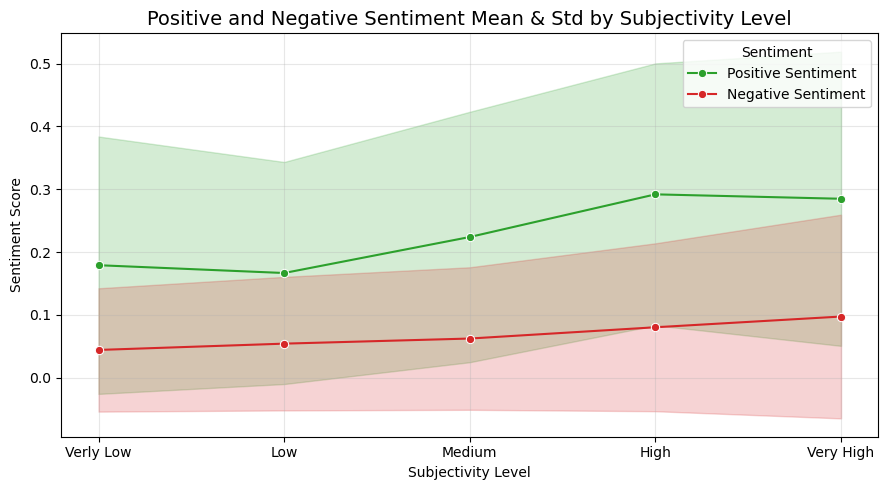

In [27]:
# plot the figure：positive and negative mean and std by stratefication
plt.figure(figsize = (9,5))


sns.lineplot(x = 'subj_level', y = 'pos_mean', data = group_stats, marker = 'o', color = 'tab:green', label = 'Positive Sentiment')
plt.fill_between(group_stats['subj_level'], 
                 group_stats['pos_mean'] - group_stats['pos_std'],
                 group_stats['pos_mean'] + group_stats['pos_std'],
                 color = 'tab:green', alpha = 0.2)
sns.lineplot(x='subj_level', y = 'neg_mean', data = group_stats, marker = 'o', color = 'tab:red', label = 'Negative Sentiment')
plt.fill_between(group_stats['subj_level'], 
                 group_stats['neg_mean'] - group_stats['neg_std'],
                 group_stats['neg_mean'] + group_stats['neg_std'],
                 color = 'tab:red', alpha = 0.2)

plt.title('Positive and Negative Sentiment Mean & Std by Subjectivity Level', fontsize=14)
plt.xlabel('Subjectivity Level')
plt.ylabel('Sentiment Score')
plt.legend(title='Sentiment')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
# Across all levels of subjectivity, positive sentiment consistently outweighs negative sentiment. 
# People tend to express more optimism than pessimism regardless of how subjective their language is.

## Negative in Stratefication

,afinn,sia_pos,sia_neg,sia_neu,sia_comp,tb_polarity
subj_level,,,,,,
Very Low,2.268829,0.204963,0.098220,0.205937,0.387436,0.170549
Low,2.865340,0.176839,0.106342,0.185433,0.436343,0.300061
Medium,3.306996,0.199421,0.113494,0.196325,0.466863,0.288939
High,3.801036,0.208562,0.133695,0.188697,0.497484,0.416683
Very High,3.411340,0.234281,0.162209,0.211449,0.504945,0.558823


<Axes: xlabel='subj_level', ylabel='sia_neg'>

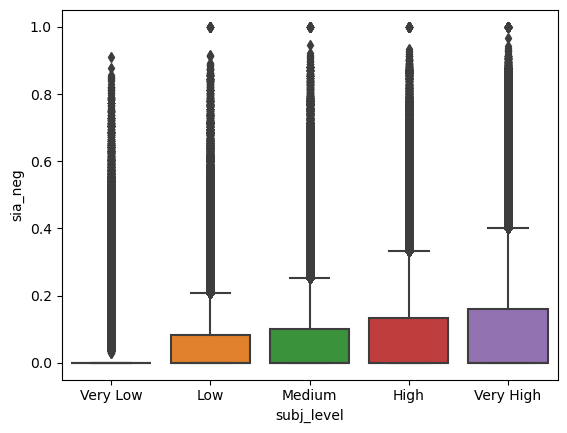

In [28]:
# stratefy the subjectivity
df['subj_level'] = pd.cut(
    df['tb_subjectivity'], 
    bins=[0, 0.2, 0.4, 0.6, 0.8, 1], 
    labels=['Very Low', 'Low', 'Medium', 'High', 'Very High']
)

display(df.groupby('subj_level')[['afinn','sia_pos', 'sia_neg', 'sia_neu', 'sia_comp', 'tb_polarity']].std())

# plot the figure: negative boxplot by stratefication
sns.boxplot(x = 'subj_level', y = 'sia_neg', data = df)

In [29]:
# As subjectivity increases, the distribution of negative sentiment scores shifts upward,
# suggesting that highly subjective texts are more emotionally negative.

## Distribution

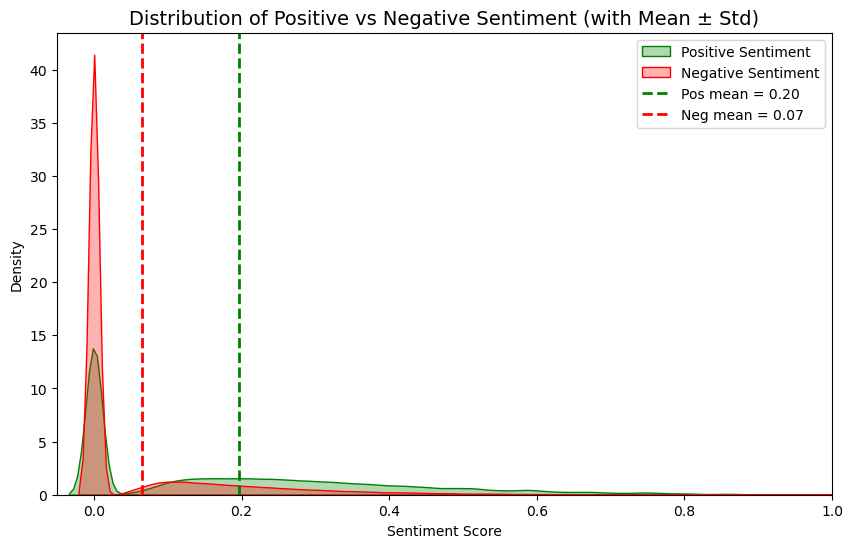

In [32]:
# plot the figure: positive and negative distribution
pos_mean, pos_std = df['sia_pos'].mean(), df['sia_pos'].std()
neg_mean, neg_std = df['sia_neg'].mean(), df['sia_neg'].std()

plt.figure(figsize=(10,6))
sns.kdeplot(df['sia_pos'], fill = True, color = 'green', alpha = 0.3, label = 'Positive Sentiment')
sns.kdeplot(df['sia_neg'], fill = True, color = 'red', alpha = 0.3, label = 'Negative Sentiment')

plt.axvline(pos_mean, color = 'green', linestyle = '--', linewidth = 2, label = f'Pos mean = {pos_mean:.2f}')
plt.axvline(neg_mean, color = 'red', linestyle = '--', linewidth = 2, label = f'Neg mean = {neg_mean:.2f}')

plt.title('Distribution of Positive vs Negative Sentiment (with Mean ± Std)', fontsize=14)
plt.xlabel('Sentiment Score')
plt.ylabel('Density')
plt.legend()
plt.xlim(-0.05, 1.0)
plt.show()

In [ ]:
# The corpus is overall more positive than negative: positive scores are higher on average and spread across a wider range, 
# while negative scores mostly cluster near zero with a thin tail.